# Simulaciones relacionadas con la entropía

## Código unificado

Este bloque junta los tres códigos de entropía y añade el parámetro `MEMORIA` a los títulos y a los nombres de los plots guardados.

In [7]:
## CAMBIA LA MEMORIA Y A AQUÍ ###########
MEMORIA = 2
A = 0.0

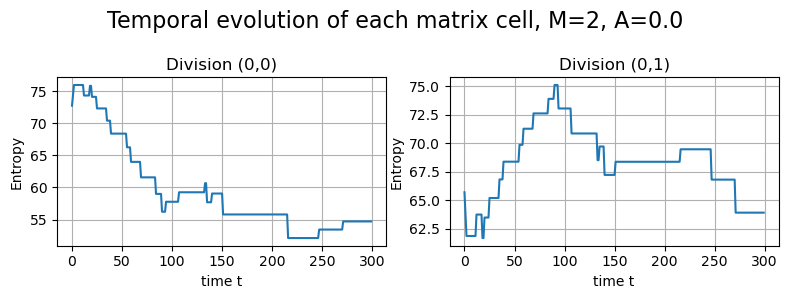

Plot guardado en: plots/ENTROPIA/entropia_celdas_M2_A0.0.png


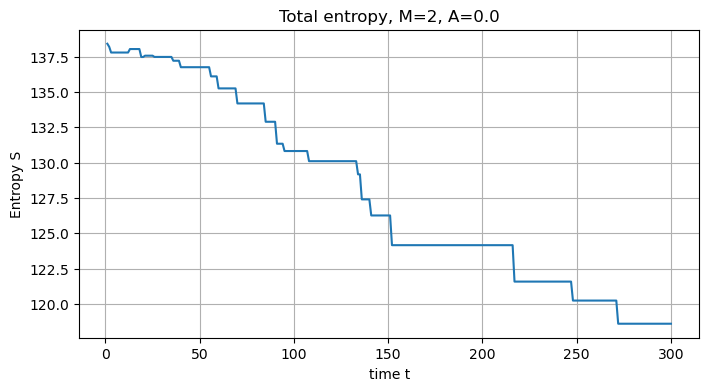

Plot guardado en: plots/ENTROPIA/entropia_total_M2_A0.0.png
Diferencia entre primer y último valor de y para M=2: -9.035415999999998


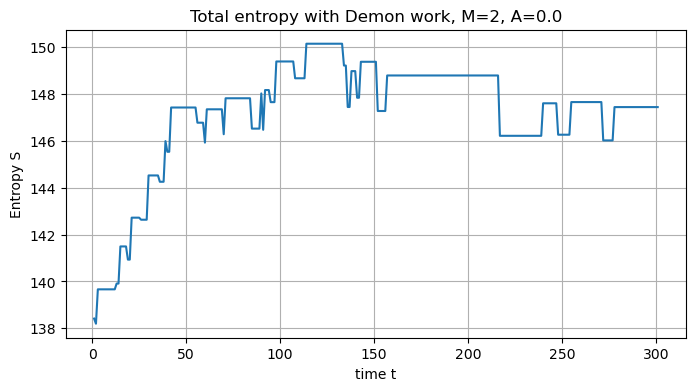

Plot guardado en: plots/ENTROPIA/entropia_DEMONIO_M2_A0.0.png


In [8]:
### CÓDIGO UNIFICADO PARA ENTROPÍA #########################

import os
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARÁMETROS
# =========================================================

carpeta_plots = "plots/ENTROPIA"

archivo_entropia_celdas = "entropy_subdivisions.txt"
archivo_entropia_total = "entropy_total.txt"
archivo_entropia_demonio = "entropy_demon.txt"

os.makedirs(carpeta_plots, exist_ok=True)


# =========================================================
# FUNCIONES
# =========================================================
def leer_matrices(nombre_archivo):
    """
    Lee un archivo donde cada bloque separado por una línea vacía
    representa una matriz en un paso temporal.

    Devuelve un array con dimensiones:
    (tiempo, filas, columnas)
    """
    with open(nombre_archivo, "r", encoding="utf-8") as f:
        texto = f.read().strip()

    bloques = texto.split("\n\n")
    matrices = []

    for bloque in bloques:
        lineas = bloque.strip().split("\n")
        matriz = []

        for linea in lineas:
            fila = list(map(float, linea.split()))
            matriz.append(fila)

        matrices.append(matriz)

    return np.array(matrices)


def leer_columna(nombre_archivo):
    """
    Lee un archivo con una columna de valores.
    Ignora líneas vacías y líneas que empiecen por #.
    """
    valores = []

    with open(nombre_archivo, "r", encoding="utf-8") as f:
        for linea in f:
            linea = linea.strip()

            if not linea or linea.startswith("#"):
                continue

            token = linea.split()[0].replace(",", ".")

            try:
                valores.append(float(token))
            except ValueError:
                pass

    return np.array(valores)


def plot_entropia_celdas(nombre_archivo, memoria, A):
    """
    Plotea la evolución temporal de la entropía en cada celda.
    """
    datos = leer_matrices(nombre_archivo)

    num_tiempos = datos.shape[0]
    num_filas = datos.shape[1]
    num_columnas = datos.shape[2]

    t = np.arange(num_tiempos)

    fig, axes = plt.subplots(
        num_filas,
        num_columnas,
        figsize=(4*num_columnas, 3*num_filas),
        sharex=True
    )

    # Por si alguna vez la matriz fuese de 1 fila o 1 columna
    if num_filas == 1 and num_columnas == 1:
        axes = np.array([[axes]])
    elif num_filas == 1:
        axes = axes[np.newaxis, :]
    elif num_columnas == 1:
        axes = axes[:, np.newaxis]

    for i in range(num_filas):
        for j in range(num_columnas):
            axes[i, j].plot(t, datos[:, i, j])
            axes[i, j].set_title(f"Division ({i},{j})")
            axes[i, j].set_xlabel("time t")
            axes[i, j].set_ylabel("Entropy")
            axes[i, j].grid(True)

    fig.suptitle(
        f"Temporal evolution of each matrix cell, M={memoria}, A={A}",
        fontsize=16
    )
    fig.tight_layout()

    nombre_salida = f"{carpeta_plots}/entropia_celdas_M{memoria}_A{A}.png"
    plt.savefig(nombre_salida, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Plot guardado en: {nombre_salida}")


def plot_entropia_total(nombre_archivo, memoria, A):
    """
    Plotea la entropía total sin demonio.
    """
    y = leer_columna(nombre_archivo)
    x = np.arange(1, len(y) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(x, y)
    plt.xlabel("time t")
    plt.ylabel("Entropy S")
    plt.title(f"Total entropy, M={memoria}, A={A}")
    plt.grid(True)

    nombre_salida = f"{carpeta_plots}/entropia_total_M{memoria}_A{A}.png"
    plt.savefig(nombre_salida, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Plot guardado en: {nombre_salida}")


def plot_entropia_demonio(nombre_archivo, memoria, A):
    """
    Plotea la entropía total con demonio.
    """
    y = leer_columna(nombre_archivo)
    x = np.arange(1, len(y) + 1)

    if y.size > 0:
        diff = y[0] - y[-1]
        print(f"Diferencia entre primer y último valor de y para M={memoria}: {diff}")
    else:
        print("No hay datos en 'y' para calcular la diferencia.")

    plt.figure(figsize=(8, 4))
    plt.plot(x, y)
    plt.xlabel("time t")
    plt.ylabel("Entropy S")
    plt.title(f"Total entropy with Demon work, M={memoria}, A={A}")
    plt.grid(True)

    nombre_salida = f"{carpeta_plots}/entropia_DEMONIO_M{memoria}_A{A}.png"
    plt.savefig(nombre_salida, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Plot guardado en: {nombre_salida}")

# =========================================================
# PROGRAMA PRINCIPAL
# =========================================================
plot_entropia_celdas(archivo_entropia_celdas, MEMORIA, A)
plot_entropia_total(archivo_entropia_total, MEMORIA, A)
plot_entropia_demonio(archivo_entropia_demonio, MEMORIA, A)

